DATA PROCESSING
Converts raw data into a format suitable for analysis and machine learning.
It may improve data quality and prepares it for modelling
OBJECTIVE:
IMPROVE DATA ACCURACY
convert categoriacal data to numeric
narmalize scale data

STEPS IN DATA PREPROCESSING

1. DATA TRANSFORMATION : Changes the formate or structure of data eg. birth -> age
2. DATA NORMALIZATION :Scaling numerical values to common range (usually 0 - 1) eg. Salary 200000 - 600000 --> 0.0 - 1.0 scale
3. DATA ENCODING : convert categorical data to numerical data eg. male->1 , female->0
4. DATA REDUCTION : Reducing datasets by removing unnecessary features eg: from age salary , height,weight --> keep age and salery

## FEATURE ENGINEERING:

is the process of creating new features or modyfing exsisting ones to improve ml models.
Features are the input variables used by the model.
good features improve model accuracy and prediction performance.

eg: suppose we have this dataset:
date|sales (FEATURE)

from the date column , we create
DAY , MONTH ,YEAR , WEEKDAY /WEEKEND (NEW FEATURE)

# TYPES OF FEATURE ENGINEERING:

1. FEATURE CREATION : creating new features with the exsisting one to provide more useful performance eg. total price = price\*quality
2. FEATURE TRANSFORMATION : Changing the scale or distribution of a featue to make it suitable for organinsation.
3. FEATURE ENCODING : Converting catogorical data into numeric formate
4. FEATURE EXTRACTION : Extracting useful information from complex data (like image , text , dates) eg: from date -> extract day , month , year
5. FEATURE SELECTION : Selecting only the most important features from a datasets to improve model performance. eg. from age,salary,height,weight -> keep age and salery


In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("Dataset.csv")

In [4]:
print(df.head())

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


## tail() : print last 5 digit of the data set


In [5]:
print(df.tail())

     survived  pclass     sex   age  sibsp  parch   fare embarked   class  \
886         0       2    male  27.0      0      0  13.00        S  Second   
887         1       1  female  19.0      0      0  30.00        S   First   
888         0       3  female   NaN      1      2  23.45        S   Third   
889         1       1    male  26.0      0      0  30.00        C   First   
890         0       3    male  32.0      0      0   7.75        Q   Third   

       who  adult_male deck  embark_town alive  alone  
886    man        True  NaN  Southampton    no   True  
887  woman       False    B  Southampton   yes   True  
888  woman       False  NaN  Southampton    no  False  
889    man        True    C    Cherbourg   yes   True  
890    man        True  NaN   Queenstown    no   True  


In [6]:
print(df.columns)

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')


In [7]:
print(df.shape)

(891, 15)


In [8]:
print(df.isnull().sum()) # to check for null values in the dataset and here age and deck have null values

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [9]:
# how to impute the null values in age and deck column

df['age'].fillna(df['age'].mean(), inplace=True) # yaha pe age column ke null values ko age column ke mean value se impute kar diya hai


df['deck'].fillna(df['deck'].mode()[0], inplace=True) # impute the null values in deck column with mode value of deck column

C:\Users\asus\AppData\Local\Temp\ipykernel_16920\1956440629.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].mean(), inplace=True) # yaha pe age column ke null values ko age column ke mean value se impute kar diya hai
C:\Users\asus\AppData\Local\Temp\ipykernel_16920\1956440629.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the 

In [10]:
print(df.isnull().sum()) # now there are no null values in the dataset after imputation in 

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       2
class          0
who            0
adult_male     0
deck           0
embark_town    2
alive          0
alone          0
dtype: int64


In [11]:
# either impute or drop if not is in use 

df.dropna(inplace=True) # yaha pr dropna() function ka use karke dataset ke sare null values ko drop kar diya hai 



In [12]:
print(df[df['age']>30])

     survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
1           1       1  female  38.0      1      0  71.2833        C  First   
3           1       1  female  35.0      1      0  53.1000        S  First   
4           0       3    male  35.0      0      0   8.0500        S  Third   
6           0       1    male  54.0      0      0  51.8625        S  First   
11          1       1  female  58.0      0      0  26.5500        S  First   
..        ...     ...     ...   ...    ...    ...      ...      ...    ...   
873         0       3    male  47.0      0      0   9.0000        S  Third   
879         1       1  female  56.0      0      1  83.1583        C  First   
881         0       3    male  33.0      0      0   7.8958        S  Third   
885         0       3  female  39.0      0      5  29.1250        Q  Third   
890         0       3    male  32.0      0      0   7.7500        Q  Third   

       who  adult_male deck  embark_town alive  alone  
1    wo

In [12]:
print(df[df['sex'] == 'female'])


     survived  pclass     sex        age  sibsp  parch     fare embarked  \
1           1       1  female  38.000000      1      0  71.2833        C   
2           1       3  female  26.000000      0      0   7.9250        S   
3           1       1  female  35.000000      1      0  53.1000        S   
8           1       3  female  27.000000      0      2  11.1333        S   
9           1       2  female  14.000000      1      0  30.0708        C   
..        ...     ...     ...        ...    ...    ...      ...      ...   
880         1       2  female  25.000000      0      1  26.0000        S   
882         0       3  female  22.000000      0      0  10.5167        S   
885         0       3  female  39.000000      0      5  29.1250        Q   
887         1       1  female  19.000000      0      0  30.0000        S   
888         0       3  female  29.699118      1      2  23.4500        S   

      class    who  adult_male deck  embark_town alive  alone  
1     First  woman     

In [13]:
# groupby function : is used to group the data based on a column and perform some operations on it

print(df.groupby('sex')["survived"].mean())  # mean() : calculates the mean value of the survived column for each group

# yaha pe groupby function ka use karke sex column ke basis pe survived column ka mean value nikal diya hai mtlb kitne male aur female log survive hue the

sex
female    0.740385
male      0.188908
Name: survived, dtype: float64


In [14]:
df_sorted = df.sort_values(by='age', ascending=True) # sort the dataset based on age column in ascending order
print(df_sorted.head())

     survived  pclass     sex   age  sibsp  parch     fare embarked   class  \
803         1       3    male  0.42      0      1   8.5167        C   Third   
755         1       2    male  0.67      1      1  14.5000        S  Second   
469         1       3  female  0.75      2      1  19.2583        C   Third   
644         1       3  female  0.75      2      1  19.2583        C   Third   
831         1       2    male  0.83      1      1  18.7500        S  Second   

       who  adult_male deck  embark_town alive  alone  
803  child       False    C    Cherbourg   yes  False  
755  child       False    C  Southampton   yes  False  
469  child       False    C    Cherbourg   yes  False  
644  child       False    C    Cherbourg   yes  False  
831  child       False    C  Southampton   yes  False  


In [15]:
# to create a new column in the dataset

 # yaha pe family_size column ko create kiya hai jisme sibsp aur parch column ke values ko add karke 1 add kar diya hai mtlb apne aap ko bhi count karna hai


df["family_size"] = df["sibsp"] + df["parch"] + 1 # sbsp : siblings/spouses , parch : parents/child
print(df.head())

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  family_size  
0    man        True    C  Southampton    no  False            2  
1  woman       False    C    Cherbourg   yes  False            2  
2  woman       False    C  Southampton   yes   True            1  
3  woman       False    C  Southampton   yes  False            2  
4    man        True    C  Southampton    no   True            1  


In [16]:
print(df['fare'].max()) # to find the maximum value in the fare column

512.3292


In [17]:
df_child = df[df['who'] == 'child']
print(df_child.head())

    survived  pclass     sex   age  sibsp  parch     fare embarked   class  \
7          0       3    male   2.0      3      1  21.0750        S   Third   
9          1       2  female  14.0      1      0  30.0708        C  Second   
10         1       3  female   4.0      1      1  16.7000        S   Third   
14         0       3  female  14.0      0      0   7.8542        S   Third   
16         0       3    male   2.0      4      1  29.1250        Q   Third   

      who  adult_male deck  embark_town alive  alone  family_size  
7   child       False    C  Southampton    no  False            5  
9   child       False    C    Cherbourg   yes  False            2  
10  child       False    G  Southampton   yes  False            3  
14  child       False    C  Southampton    no   True            1  
16  child       False    C   Queenstown    no  False            6  


In [18]:
df.to_csv("cleaned_dataset.csv", index=False) # to save the cleaned dataset in a new csv file

In [19]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

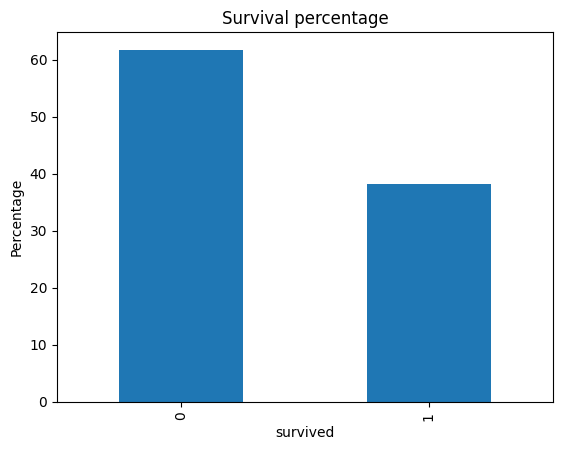

In [21]:
# Survival Rate

survival_rate = df['survived'].value_counts(normalize=True) * 100 # calculate % of survived and not survived passengers
survival_rate.plot(kind='bar')
plt.title("Survival percentage")
plt.ylabel("Percentage")
plt.show() # act as print statement for the plot to show the graph

In [ ]:
# Survival Percentage : 65% of people survived

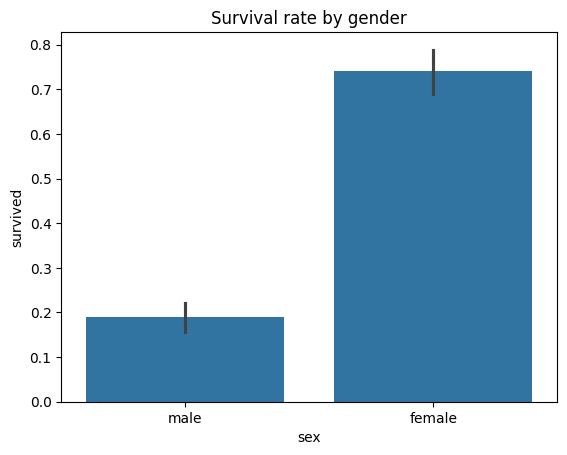

In [22]:
sns.barplot(x='sex' , y='survived', data=df) # to plot the survival rate based on
plt.title("Survival rate by gender")
plt.show()

In [47]:
# Survival rate by gender : More females survived than male

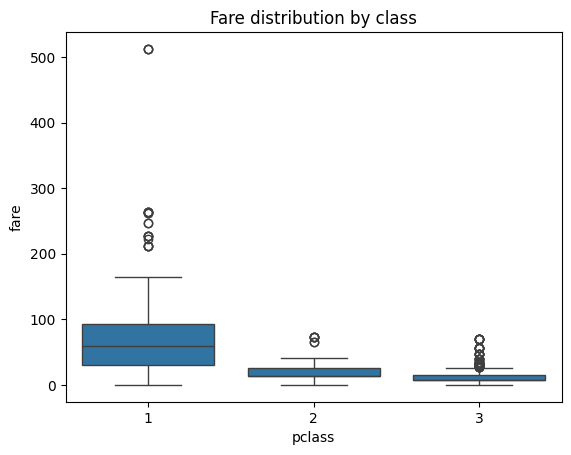

In [23]:
sns.boxplot(x='pclass', y='fare', data=df) # to plot the boxplot of fare based on pclass
plt.title("Fare distribution by class")
plt.show()

In [49]:
# class 1 people paid more fare than class 2 and class 3 people
# dot in the graph are outliers and the box represents the interquartile range 
# and the line in the box represents the median value of the fare column for each class

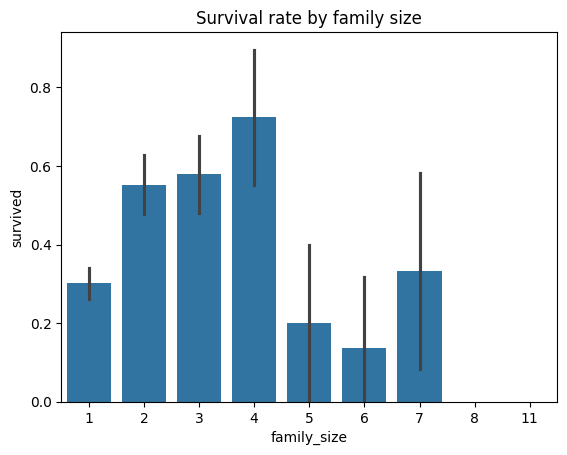

In [24]:
df['famil_size'] = df["sibsp"] + df["parch"] 
sns.barplot(x='family_size', y='survived', data=df) # to plot the survival rate based on family size
plt.title("Survival rate by family size")
plt.show()

In [ ]:
# the family_size 4 survived the most and family_size 6 survived the least 

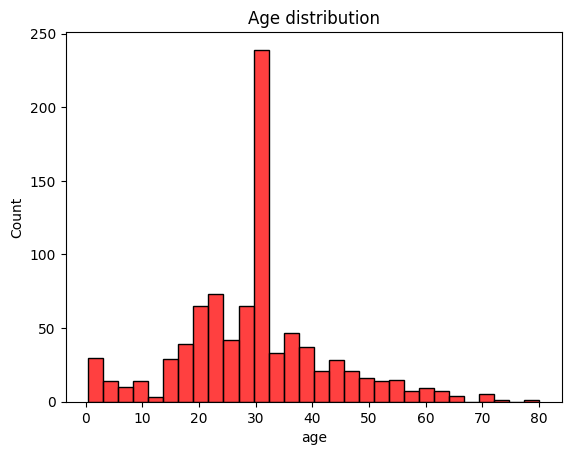

In [25]:
sns.histplot(df['age'], color="red")
plt.title("Age distribution")
plt.show()

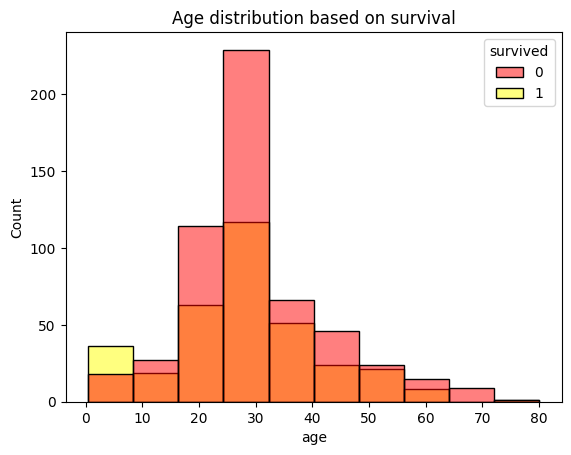

In [25]:
sns.histplot(data=df,x="age",hue="survived" , palette=["red" , "yellow"], bins=10) # red = not survived , blue = survived
plt.title("Age distribution based on survival") # bins= describes ye karta hai ki kitna zoom hoga kitna nahi
plt.show()

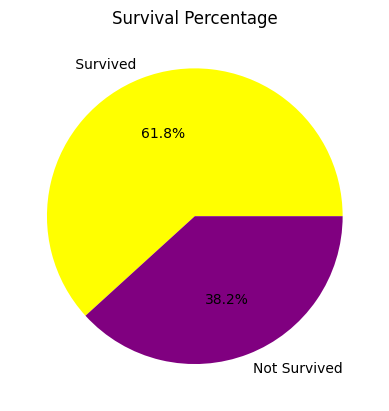

In [27]:
survival = df["survived"].value_counts()
plt.pie(survival,labels = [" Survived" , "Not Survived"], autopct="%1.1f%%" , colors=["yellow" , "purple"])
plt.title("Survival Percentage")
plt.show()

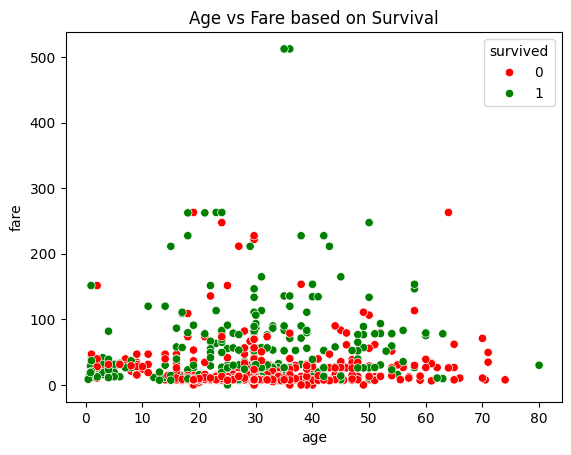

In [28]:
sns.scatterplot(x='age', y='fare', hue='survived', data=df, palette=["red", "green"]) # red = not survived , green = survived
plt.title("Age vs Fare based on Survival")
plt.show()

In [36]:
pip install sklearn

  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [15 lines of output]
      The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
      rather than 'sklearn' for pip commands.
      
      Here is how to fix this error in the main use cases:
      - use 'pip install scikit-learn' rather than 'pip install sklearn'
      - replace 'sklearn' by 'scikit-learn' in your pip requirements files
        (requirements.txt, setup.py, setup.cfg, Pipfile, etc ...)
      - if the 'sklearn' package is used by one of your dependencies,
        it would be great if you take some time to track which package uses
        'sklearn' instead of 'scikit-learn' and report it to their issue tracker
      - as a last resort, set the environment variable
        SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True to avoid this error
      
      More information is available at
      https://github.com/scikit-learn/sklearn-

In [35]:
%pip install -U scikit-learn


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [34]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [28]:
df["embarked"].fillna("S",inplace=True)

C:\Users\asus\AppData\Local\Temp\ipykernel_16920\4143081436.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["embarked"].fillna("S",inplace=True)


In [29]:
df["deck"].fillna("Unknown", inplace=True )

C:\Users\asus\AppData\Local\Temp\ipykernel_16920\1193070204.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["deck"].fillna("Unknown", inplace=True )


# removing all the unneccessary column 
# to drop the columns which are not in use and axis=1 means we are dropping columns not rows 


In [30]:
df.drop(["class" ,"who", "adult_male" , "deck" , "embark_town","alive"], axis=1, inplace=True) 

In [31]:
# convert categorical variables to numerical variables using one-hot encoding

df["sex"] = df["sex"].map({"male": 0, "female": 1})
df["embarked"] = df["embarked"].map({"S":0,"C":1,"Q":2})
df["alone"] = df["alone"].map({False:0, True:1})
df.fillna(0, inplace=True) # to fill any remaining null values with 0

In [32]:
# x is my input variable that i give the model to learn 
# df is the datafame where dataset is stored
# and here we drop the survived column from the dataframe 
# and store it in x variable (after removing the survived column) 
# and we store the survived column in y variable
# because survived column is our target variable that we want to predict

x= df.drop("survived" , axis=1) 
y=df["survived"]

In [37]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2, random_state=42) 
# to split the dataset into training and testing set
# test_size=0.2 means 20% of the dataset will be used for testing
# random_state=42 is used to get the same random split every time we run the code


In [38]:
model = LogisticRegression(max_iter=1000) # to create an instance of the LogisticRegression model and max_iter is used to set the maximum number of iterations for the solver to converge
model.fit(x_train, y_train) # to train the model on the training data

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [39]:
# predict output for the test set

y_pred = model.predict(x_test)

In [40]:
# evaluate the model

print("Accuracy:", accuracy_score(y_test, y_pred))       

Accuracy: 0.797752808988764


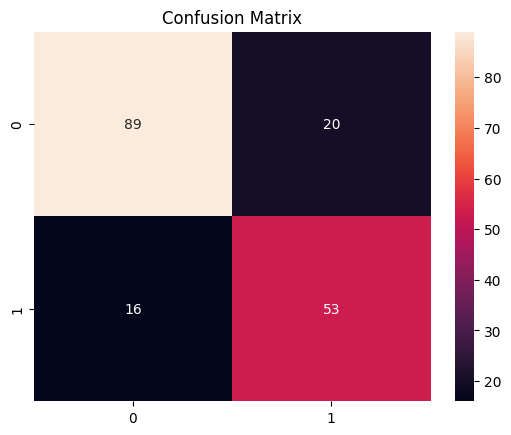

In [41]:
cm = confusion_matrix(y_test, y_pred) # logic to create confusion matrix.
sns.heatmap(cm, annot=True, fmt="d") # to plot the confusion matrix as a heatmap
plt.title("Confusion Matrix")
plt.show()

# annot=True : to show the numbers in the heatmap
# fmt="d" : to format the numbers as integers in the heatmap
